
#**Assignment 4: Generative Adversarial Networks (GANs) (*Due date: November 3, 2025*)**

# Overview
## Total [100 Points]
In this assignment, you will be implementing your own GAN network (both the generator and discriminator), and train it on the MNIST dataset.

### Submission:
You will need to submit the following to Canvas:  
1. your notebook.ipynb (with all the outputs shown)

Reference Paper: [UNSUPERVISED REPRESENTATION LEARNING WITH DEEP CONVOLUTIONAL GENERATIVE ADVERSARIAL NETWORKS](https://arxiv.org/pdf/1511.06434.pdf)

A Generative Adversarial Network (GAN) is a neural network model consisting of two modules, termed the generator $G$ and the discriminator $D$.

![](https://drive.google.com/uc?export=view&id=1Q4sz0dHkr1v2cm3wdKDEWoHkl9PkBdYx)

# Setting up

We'll start by importing some dependancies, You have seen most of these from previous assignments.

In [1]:
import argparse
import os
import math

import numpy as np
import matplotlib.pyplot as plt

import torchvision.transforms as transforms
from torchvision.utils import save_image

from torch.utils.data import DataLoader
from torch.autograd import Variable
from torchvision.datasets import MNIST, CelebA
import torchvision.utils as vutils

from torch import nn
import torch.nn.functional as F
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Data
Let's load and transform the [MNIST dataset](https://pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html) and wrap it in a [DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader). We'll also apply a [transform](https://pytorch.org/vision/0.11/transforms.html):
- [torchvision.transforms.ToTensor](https://pytorch.org/vision/0.11/transforms.html#torchvision.transforms.ToTensor)
- [torchvision.transforms.Resize](https://pytorch.org/vision/0.11/transforms.html#torchvision.transforms.Resize)
- [torchvision.transforms.Normalize](https://pytorch.org/vision/0.11/transforms.html#torchvision.transforms.Normalize)

In [2]:
img_size = 28
traindataset = MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize([img_size, img_size]),
        transforms.Normalize((0.5,), (0.5,))
    ])
)

batch_size = 64
trainloader = DataLoader(
    traindataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    drop_last=True,
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.76MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.00MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


# Model

## Defining a Generator and a Discriminator

### Generator Implementation [20 Points]

Let's define the generator $G$. Some useful documentation:
- [torch.nn.ConvTranspose2d](https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html) - we are upsampling from a lower dimensionality to a higher one.
- [torch.nn.BatchNorm2d](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html)
- [torch.nn.ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
- [torch.nn.Tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html)

In [14]:
latent_dim = 100
channels = 1
num_of_gen_filters = 64

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # TODO: Define the Generator network.
        # Use ConvTranspose2d layers to turn the input noise into an image.
        # Add BatchNorm2d and ReLU after each layer (except the last).
        # The last layer should use Tanh to get pixel values between -1 and 1.
        # The output should be a 1-channel image.
        self.main = nn.Sequential(
            # Input: (batch_size, latent_dim, 1, 1)
            # Project the latent vector Z into a 7x7 feature map
            nn.ConvTranspose2d(
                in_channels=latent_dim,
                out_channels=num_of_gen_filters * 4,
                kernel_size=7, # Creates a 7x7 base
                stride=1,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(num_of_gen_filters * 4),
            nn.ReLU(True),
            # State size: (num_of_gen_filters * 4) x 7 x 7 = 12544

            # Upsample to 14x14
            nn.ConvTranspose2d(
                in_channels=num_of_gen_filters * 4,
                out_channels=num_of_gen_filters * 2,
                kernel_size=4,
                stride=2, # Doubles the size
                padding=1, # Formula: (7-1)*2 - 2*1 + 4 = 14
                bias=False
            ),
            nn.BatchNorm2d(num_of_gen_filters * 2),
            nn.ReLU(True),
            # State size: (num_of_gen_filters * 2) x 14 x 14 = 25088

            # Final upsample to 28x28
            nn.ConvTranspose2d(
                in_channels=num_of_gen_filters * 2,
                out_channels=channels,
                kernel_size=4,
                stride=2, # Doubles the size
                padding=1, # Formula: (14-1)*2 - 2*1 + 4 = 28
                bias=False
            ),

            # Final activation layer
            # Output pixel values between -1 and 1
            nn.Tanh()
            # State size: (channels) x 28 x 28 = 784
        )

    def forward(self, input):
        # TODO: run the generator network
        reshaped_input = input.view(-1, latent_dim, 1, 1)
        output = self.main(reshaped_input)
        return output


### Discriminator Implementation [20 Points]

Let's also define the discriminator $D$. Some useful documentation:
- [torch.nn.Conv2d](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- [torch.nn.BatchNorm2d](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html)
- [torch.nn.LeakyReLU](https://pytorch.org/docs/stable/generated/torch.nn.LeakyReLU.html)
- [torch.nn.Sigmoid](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html)

In [16]:
num_of_disc_filters = 64

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        # TODO: Define the Discriminator network.
        # Use Conv2d layers to downsample the input image.
        # Add LeakyReLU after each layer, and BatchNorm2d except for the first and last layers.
        # The final layer should use Sigmoid to output a probability.
        # The output should be a single value for each image in the batch.
        self.main = nn.Sequential(
            # Input: (batch_size, channels, 28, 28)
            # No BatchNorm on the first layer.
            nn.Conv2d(
                in_channels=channels,
                out_channels=num_of_disc_filters,
                kernel_size=4,
                stride=2, # Downsample to 14x14
                padding=1, # Formula: (28-4+2)/2 + 1 = 14
                bias=False
            ),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (num_of_disc_filters) x 14 x 14 = 12544

            # Downsample to 7x7
            nn.Conv2d(
                in_channels=num_of_disc_filters,
                out_channels=num_of_disc_filters * 2,
                kernel_size=4,
                stride=2, # Downsample to 7x7
                padding=1, # Formula: (14-4+2)/2 + 1 = 7
                bias=False
            ),
            nn.BatchNorm2d(num_of_disc_filters * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (num_of_disc_filters * 2) x 7 x 7 = 6272

            # Final layer: Conv to 1x1
            # No BatchNorm on the last layer.
            nn.Conv2d(
                in_channels=num_of_disc_filters * 2,
                out_channels=1,
                kernel_size=7, # Kernel size is 7 to match input 7x7
                stride=1,
                padding=0, # Formula: (7-7+0)/1 + 1 = 1
                bias=False
            ),

            # Final activation to get a probability
            nn.Sigmoid()
            # State size: (1) x 1 x 1 = 1
        )

    def forward(self, input):
        # TODO: Run the input through the network
        output = self.main(input)
        return output.view(-1, 1)

### Weight initialization [10 Points]

We'll use a [torch.nn.init.normal_](https://pytorch.org/docs/stable/nn.init.html#torch.nn.init.normal_) initialization for most weights, but we'll initialize bias terms to be 0 (a common practice) with [torch.nn.init.constant_](https://pytorch.org/docs/stable/nn.init.html#torch.nn.init.constant_):

In [17]:
def weights_init(m):
    # TODO: Initialize weights for Conv and BatchNorm layers.
    class_name = m.__class__.__name__
    if 'Conv' in class_name: # conv weights near 0
        #TODO: For Conv layers, use normal distribution with mean 0 and std 0.02.
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in class_name: # norm weights near 1
        # TODO: For BatchNorm layers, use normal distribution with mean 1 and std 0.02 for weights, and set biases to 0.
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)

We can now initialize both components of the GAN, and apply our custom weight initialization:

In [18]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

generator.apply(weights_init)
discriminator.apply(weights_init)

print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 1, ke

# Training

A GAN is trained using two steps of backpropagation. Step 1: updating the weights of the Discriminator $D$, and step 2: updating the weights of the Generator $G$.

**Step 1: Updating the weights of $D$**

We feed the discriminator $D$ some real images ($\mathbf{x}_{\text{real}}$) and see what it misclassifies using [Binary Cross Entropy Loss](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html):

$$\text{loss}_{\text{real}} = \text{BCELoss}\left(D(\mathbf{x}_{\text{real}}), \mathbf{1}\right)$$

where the loss is computed against $\mathbf{1}$ (a vector of $1$'s) because the label for all real images is $1$.

We do the same thing with fake images, except that the loss is now computed against $\mathbf{0}$ (a vector of $0$'s) because the label for all fake images is $0$:

$$\text{loss}_{\text{fake}} = \text{BCELoss}\left(D(\mathbf{x}_{\text{fake}}), \mathbf{0}\right)$$

where $\mathbf{x}_{\text{fake}} = G(\mathbf{z})$, with $\mathbf{z}$ being random noise. That is, the fake images are the outputs of the generator $G$, which has been fed random noise as input. We could therefore write:

$$\text{loss}_{\text{fake}} = \text{BCELoss}\left(D(G(\mathbf{z})), \mathbf{0}\right)$$

Importantly, backpropagation ***is not applied*** to the generator $G$ during this phase, and gradients computed do not take the processes of the generator $G$ into account.

In PyTorch, this is achieved by calling [`.detach()`](https://pytorch.org/docs/stable/generated/torch.Tensor.detach.html) on $\mathbf{x}_{\text{fake}}$. This is done because we want to train the generator $G$ to ***fool*** the discriminator $D$, rather than agree with it. We optimize only the parameters of the discriminator $D$ in this phase. We can also define the total loss as follows:

$$\text{loss}_{\text{disc}} = \text{loss}_{\text{real}} + \text{loss}_{\text{fake}}$$

The right side of the image can be interpreted as follows.

We feed fake images into the discriminator $D$ as before:

$$\text{loss}_{\text{gen}} = \text{BCELoss}\left(D(\mathbf{x}_{\text{fake}}), \mathbf{0}\right)$$

Importantly, backpropagation ***is applied*** to the generator $G$ during this phase (we simply do not call `.detach()` here). This is done because we are now training the generator $G$.

We also need to ***flip the sign*** of the gradients before updating the generator $G$, because we again want to ***fool*** the discriminator, rather than produce things it can learn. That is, we need to optimize the generator $G$ so as to cause the discriminator $D$ to make more mistakes. We optimize only the parameters of the generator $G$ in this phase.

**Step 2: Updating the weights of $G$**

One way to update the weights of $G$ is to flip the gradients (*-1) resulting from backpropagating through the discriminator and backpropagate through the generator, as depicted in the right side of the above figure.

**Another way, that is easier to implement in PyTorch, that we will implement in this assignment, is explained below:**

Rather than flipping the sign of the gradients, we simply compute

$$\text{loss}_{\text{gen}} = \text{BCELoss}\left(D(\mathbf{x}_{\text{fake}}), \mathbf{1}\right)$$

Importantly, we are computing the loss against $\mathbf{1}$ ***rather than*** $\mathbf{0}$.

It is worth thinking for a moment about why this works. We are asking the discriminator $D$ whether the images are real or fake, but of course all the images $\mathbf{x}_{\text{fake}} = G(\mathbf{z})$ are fake. If the discriminator $D$ were perfect, it would predict $0$ (fake) for everything.

This is precisely the opposite of what we want for the generator $G$, because it means the generator $G$ is not fooling the discriminator $D$ at all, and so the loss will be large in this situation.

Conversely, if the discriminator $D$ predicts $1$ for everything, we don't need to update the generator $G$ at all, because it has fooled the discriminator $D$ into classifying all the fake images as real.

This is the implementation we will use.

Now we'll define the loss function ([torch.nn.BCELoss](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html)) and the optimizer ([torch.optim.Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html)).

In [19]:
adversarial_loss = torch.nn.BCELoss()

optim_gen = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas = (0.5, 0.999)
)
optim_disc = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas = (0.5, 0.999)
)

### Training Loop [25 Points]

In [25]:
# torch.manual_seed(42) # seeds random number generation for reproducibility
fixed_noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
num_epochs = 5


def train_mnist():
    iters = 0 # total number of batches seen by the models

    img_list = []
    training_losses_disc = []
    training_losses_gen = []

    for epoch in range(num_epochs):
        # TODO:
        # ensure training mode
        generator.train()
        discriminator.train()


        for idx, (imgs, _) in enumerate(trainloader):

            # adversarial ground truths
            # 0 = fake, 1 = real
            real_labels = torch.full(
                [imgs.size(0), 1], # vector of size batch_size X 1
                1.0,               # filled with 1's
                dtype=imgs.dtype   # ensure float32
            ).to(device)

            fake_labels = torch.full(
                [imgs.size(0), 1], # vector of size batch_size X 1
                0.0,               # filled with 0's
                dtype=imgs.dtype   # ensure float32
            ).to(device)

            # TODO:
            """TRAIN DISCRIMINATOR"""

            # zero gradients for discriminator
            optim_disc.zero_grad()

            # attach the img to the device
            real_imgs = imgs.to(device)

            # feed real images to the discriminator
            output_disc_real = discriminator(real_imgs)

            # compare discriminator predictions with all 1's (all real)
            real_loss = adversarial_loss(output_disc_real, real_labels)
            real_loss.backward()

            # feed fake images (from noise) to the generator)
            noise = torch.randn(imgs.size(0), latent_dim, 1, 1, device=device)
            fake_imgs = generator(noise)

            # note use of .detach() to avoid updating generator
            output_disc_fake = discriminator(fake_imgs.detach())

            # compare discriminator predictions with all 0's (all fake)
            fake_loss = adversarial_loss(output_disc_fake, fake_labels)
            fake_loss.backward()

            # compute total loss for the discriminator and update
            disc_loss = real_loss + fake_loss
            optim_disc.step() # update just discriminator params

            # TODO:
            """TRAIN GENERATOR"""

            # zero gradients for generator
            optim_gen.zero_grad()

            # note there is no .detach() because we do want to update generator
            output_disc_fake = discriminator(fake_imgs)

            # compare discrimnator predictions with all 1's
            # we want to trick the discriminator
            gen_loss = adversarial_loss(output_disc_fake, real_labels)
            gen_loss.backward()
            optim_gen.step() # update just generator params

            # logging
            if idx % 50 == 0:
                print(
                    f'[{epoch:4d}/{num_epochs}][{idx:3d}/{len(trainloader)}]\t'
                    f'Loss_Discriminator: {disc_loss.item():.4f}\t'
                    f'Loss_Generator: {gen_loss.item():.4f}'
                )
                training_losses_disc.append(disc_loss.item())
                training_losses_gen.append(gen_loss.item())

            # plot the real images and the generations for comparison
            # You can manipulate the number below to control how many images to store (no need to store a lot!)
            if idx % 10 == 0:
              fake = generator(fixed_noise).detach().cpu()
              img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

    return img_list, training_losses_disc, training_losses_gen

# run the training function for the MNIST data
img_list, training_losses_disc, training_losses_gen = train_mnist()

[   0/5][  0/937]	Loss_Discriminator: 2.9184	Loss_Generator: 2.0041
[   0/5][ 50/937]	Loss_Discriminator: 0.5326	Loss_Generator: 1.9364
[   0/5][100/937]	Loss_Discriminator: 0.6042	Loss_Generator: 1.8703
[   0/5][150/937]	Loss_Discriminator: 0.6795	Loss_Generator: 1.4601
[   0/5][200/937]	Loss_Discriminator: 0.8233	Loss_Generator: 1.1177
[   0/5][250/937]	Loss_Discriminator: 0.5520	Loss_Generator: 2.1153
[   0/5][300/937]	Loss_Discriminator: 0.5516	Loss_Generator: 2.3665
[   0/5][350/937]	Loss_Discriminator: 0.8942	Loss_Generator: 3.1316
[   0/5][400/937]	Loss_Discriminator: 0.5376	Loss_Generator: 2.9782
[   0/5][450/937]	Loss_Discriminator: 0.8526	Loss_Generator: 2.5861
[   0/5][500/937]	Loss_Discriminator: 1.4324	Loss_Generator: 3.0690
[   0/5][550/937]	Loss_Discriminator: 0.7132	Loss_Generator: 1.9335
[   0/5][600/937]	Loss_Discriminator: 0.6167	Loss_Generator: 2.5944
[   0/5][650/937]	Loss_Discriminator: 1.1545	Loss_Generator: 3.1853
[   0/5][700/937]	Loss_Discriminator: 0.6659	Los

# Plotting and Visualizing

### Plot the losses [5 Points]

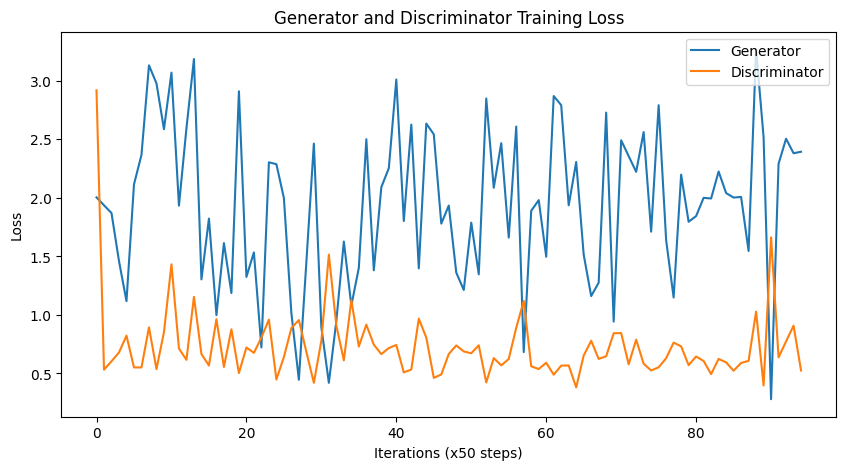

In [31]:
# TODO: plot the training loss for (1) discriminator, (2) generator, (3) total in one figure
def plot_training_results(training_losses_disc, training_losses_gen):
  plt.figure(figsize=(10, 5))
  plt.title("Generator and Discriminator Training Loss")
  plt.plot(training_losses_gen, label="Generator")
  plt.plot(training_losses_disc, label="Discriminator")

  # Note: Your training loop saved losses every 50 batches,
  # so the x-axis represents "iterations (x50 steps)".
  plt.xlabel("Iterations (x50 steps)")
  plt.ylabel("Loss")
  plt.legend()
  plt.savefig("training_losses.png")
  pass

plot_training_results(training_losses_disc, training_losses_gen)

### Plot the fake images [5 Points]

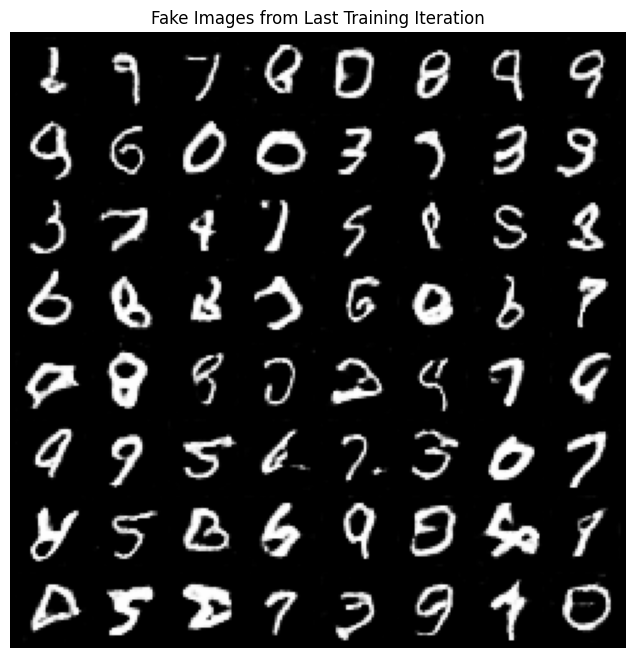

In [41]:
# TODO: visualize the fake images
def visualize_fake_images(img_list):
    if not img_list:
        print("Image list is empty. Cannot visualize fake images.")
        return

    # Create a figure to display the images
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title("Fake Images from Last Training Iteration")

    # Get the last image grid from the list
    # Move it to the CPU (in case it's on CUDA)
    # Transpose it from (C, H, W) to (H, W, C) for matplotlib
    final_grid_numpy = np.transpose(img_list[-1].cpu(), (1, 2, 0))

    # Set the image to be plotted
    plt.imshow(final_grid_numpy)
    plt.show()

visualize_fake_images(img_list)

# Research Questions [15 points]

The following are questions we ask you to research. Please answer each question in **1-2 short paragraphs**. Each answer should include at least **three references** from which the answer is compiled.

(1) Can GANs learn a full data distribution or do they suffer from limitations? <br>

Theoratically, GANs can learn a full data distribution. However, in practice, it fails to do so as they suffer from limitations. Firstly, Mode Collapse occurs when the model oscillates and unable to achieve Nash equilibrium as the discriminator continuously rejects images by the generator. This is usually a result of poor generalization. Additionally, there are 2 main types of model collapse: either most of the modes from the input data are absent or only a subset of particular modes is learned by the generator. This is largely due to an ill-suited objective function. Another limitation of GAN would be non-convergence and instability. This is largely caused by gradient vanishing problem whereby the discriminator can easily differentiate between real and fake images. Ideally, the discriminator minimizes the cross-entropy loss function while the generator maximises it. However, if the discriminator has a high confidence, it will consistently reject images generated by the generator and hence the generator's gradient vanishes. <br>

*[1]: Arora, Sanjeev & Zhang, Yi. (2017). Do GANs actually learn the distribution? An empirical study. 10.48550/arXiv.1706.08224.

*[2]: Saxena, D., & Cao, J. (2021). Generative Adversarial Networks (gans). ACM Computing Surveys, 54(3), 1–42. https://doi.org/10.1145/3446374

*[3]: Schoen, A., Blanc, G., Gimenez, P.-F., Han, Y., Majorczyk, F., & Me, L. (2024). A tale of two methods: Unveiling the limitations of Gan and the rise of Bayesian networks for Synthetic Network Traffic Generation. 2024 IEEE European Symposium on Security and Privacy Workshops (EuroS&amp;Amp;PW), 273–286. https://doi.org/10.1109/eurospw61312.2024.00036

(2) How does a conditional GAN (cGAN) differ from a vanilla GAN?

A conditional GAN is an extension of a vanilla GAN by introducing more information such as labels and conditions. This helps the generator produce data that is tailored to these specific criterias. Mainly, the input will consist of both the noise vector and the condition introduced, as compared to merely the noise vector in a vanilla GAN. This allows for targeted data generation given the conditional variable y introduced.

*[1]: https://aws.amazon.com/what-is/gan/

*[2]: https://medium.com/@vedasree812/understanding-gans-a-deep-dive-into-vanilla-gans-and-conditional-gans-07dc83f2b6bf

*[3]: https://www.geeksforgeeks.org/deep-learning/generative-adversarial-network-gan/

(3) How can we evaluate the quality of a generated image?

There are 6 key metrics when it comes to evaluating the quality of a generated image. Firstly, Fréchet Inception Distance (FID) refers to comparing the feature distribution of the real images to the generated image. By taking a pretrained surrogate model and passing both real and generated images through it, we get back feature embeddings and FID measures the distance between the 2 distributions. A lower FID indicates high similarity while a higher FID indicates low similarity. Secondly, Clip Maximum-Mean Discrepancy refers to the use of embeddings from a pretrained CLIP model to compare feature distributiuons. Unlike FID, we do not assume Gaussian distribution and hence use the kernal function to compare how different the distributions are. Lower CMMD score suggests high similarity. Thirdly, we have prompt alignment metrics such as the CLIPScore that passes through the image and its prompt into a pretrained CLIP model. This returns the embeddings and the CLIPScore, bounded by 0 and 100. Higher score refers to higher similarity. Additionally, we have Peak Signal-to-Noise Ratio whereby it measures the pixel-level similarity between the generated image and the real image. Higher PSNR value suggests higher image quality. Moreover, Structural Similarity Index compares the local patterns of pixel intensities and models human visual perception, a feature that PSNR does not have, with a range from -1 to 1 where 1 refers to perfect similarity. Lastly, we have Learned Perceptual Image Patch Similarity whereby it measures perceptual similairty between images with the use of features from pre-trained neural networks. This captures high-level perceptual differences as compared to PSNR and SSIM that compares pixel-wise differences.

*[1]: https://huggingface.co/blog/PrunaAI/objective-metrics-for-image-generation-assessment

*[2]: https://dagshub.com/blog/how-to-evaluate-generative-image-models/

*[3]: https://medium.com/genusoftechnology/evaluating-generative-ai-a-comprehensive-guide-with-metrics-methods-visual-examples-2824347bfac3